# **Lab 6. Image Segmentation.**

Frolova AI

a.frolova@innopolis.university

Изначально код выполняла в другом ноутбуке. Поставила большое количество эпох, но так как выполнялось слишком долго, досрочно завершила после 20 эпох. В этом ноутбуке доработала так, что загружается чекпоинт, можно посмотреть то, что уже обучилось, вывести промежуточные результаты, и продолжить обучение без потерь.

В конце вставила скриншоты из прошлого ноутбука, что получалось по ходу обучения на предыдущих эпохах.

You have to train your own U-Net model to segment imges from a datset you choose. You can take a ready-to-go dataset with prepared pairs of images and masks or create your own.

This is an example:
https://www.cvat.ai/resources/blog/top-datasets-semantic-segmentation

Requirements:
1. Fully prepared code for training your model using pytorch merthods (no pretrained models)

2. You should present your dataset and explain its segmentaion problem

3. Show results after training your architecture in the form of generated masks. You can use `segment` function we have used during the lab of create by your own.

4. Take randomly 3-5 examples from test set and show image, its `label` mask and predicted mask by the model.

<img alt="SAM" src="https://lh7-us.googleusercontent.com/5HvAHCdds1I4VE0-KPNm2pPuEgg9IVlwLhLGbJJFtcOBgT_EdOq0hrW75csAIOK2KFjkdQusDU66x_aokYiatHheGv73ZfXnqD1Tu6BZCc4xdMS8QDnan1gymDF1iLP9pSUgJEHuqPgpIASSvCr06GI" width=600 height=200>




In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision import transforms as T
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import random
import os
from PIL import Image

# Настройка устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Устройство: {device}")

IMG_SIZE = 96
BATCH_SIZE = 24
NUM_CLASSES = 3
NUM_EPOCHS = 50  # Максимальное количество эпох, изначально перегнула))
LEARNING_RATE = 1e-3
USE_DATA_SUBSET = 1500
PRINT_EVERY = 5 # Через какое кол-во эпох выводится результат
PATIENCE = 10

# Пути для сохранения
CHECKPOINT_DIR = "checkpoints"
MODEL_NAME = "unet_improved"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"\n Параметры:")
print(f"  - Размер: {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Макс. эпох: {NUM_EPOCHS}")
print(f"  - Batch size: {BATCH_SIZE}")

 Устройство: cpu

 Параметры:
  - Размер: 96x96
  - Макс. эпох: 50
  - Batch size: 24


# Архитектура модели

In [10]:
class UNetAdvanced(nn.Module):
    """U-Net"""
    def __init__(self):
        super().__init__()
        
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(2)
        
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool2d(2)
        
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.pool3 = nn.MaxPool2d(2)
        
        self.enc4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        self.pool4 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 1024, 3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, 3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.2)
        )
        
        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = nn.Sequential(
            nn.Conv2d(1024, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # Output
        self.final = nn.Conv2d(64, NUM_CLASSES, 1)
        
    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)
        
        e4 = self.enc4(p3)
        p4 = self.pool4(e4)
        
        # Bottleneck
        b = self.bottleneck(p4)
        
        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)
        
        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        
        return self.final(d1)

# Загрузка датасета

Использую датасет Oxford Pets.

In [11]:
class OxfordDataset(Dataset):
    """Датасет для Oxford Pets"""
    def __init__(self, data, img_size=96, augment=False):
        self.data = data
        self.img_size = img_size
        self.augment = augment
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img, mask = self.data[idx]
        
        # Ресайз
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        
        # Аугментация
        if self.augment:
            if random.random() > 0.5:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
                mask = mask.transpose(Image.FLIP_LEFT_RIGHT)
            
            if random.random() > 0.5:
                angle = random.randint(-15, 15)
                img = img.rotate(angle, Image.BILINEAR, expand=False)
                mask = mask.rotate(angle, Image.NEAREST, expand=False)
        
        # В тензоры
        img = T.ToTensor()(img)
        img = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(img)
        
        # Маска
        mask = np.array(mask)
        mask = torch.from_numpy(mask).long()
        mask = mask - 1  # 1,2,3 -> 0,1,2
        mask = torch.clamp(mask, min=0, max=2)
        
        return img, mask

print("\n Загрузка данных...")

# Загрузка датасета
full_dataset = OxfordIIITPet(root="./data", split="trainval", 
                            target_types="segmentation", download=True)

# Используем подмножество
indices = list(range(min(USE_DATA_SUBSET, len(full_dataset))))
subset = Subset(full_dataset, indices)

# Разделение на train/val
train_size = int(0.8 * len(subset))
val_size = len(subset) - train_size
train_data, val_data = random_split(subset, [train_size, val_size])

# Создание датасетов
train_dataset = OxfordDataset(train_data, IMG_SIZE, augment=True)
val_dataset = OxfordDataset(val_data, IMG_SIZE, augment=False)

# DataLoader'ы
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")


 Загрузка данных...
Train: 1200 | Val: 300


In [12]:
def calculate_accuracy(output, target):
    """Вычисление точности"""
    pred = output.argmax(dim=1)
    correct = (pred == target).float()
    return correct.mean().item()

def calculate_dice(output, target, smooth=1e-6):
    """Вычисление Dice коэффициента"""
    pred = output.argmax(dim=1)
    dice_scores = []
    
    for cls in range(NUM_CLASSES):
        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()
        
        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        
        dice = (2. * intersection + smooth) / (union + smooth)
        dice_scores.append(dice.item())
    
    return np.mean(dice_scores)

def train_epoch(model, loader, criterion, optimizer):
    """Одна эпоха обучения"""
    model.train()
    total_loss = 0
    total_acc = 0
    total_dice = 0
    
    pbar = tqdm(loader, desc='Train')
    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        loss.backward()
        optimizer.step()
        
        acc = calculate_accuracy(outputs, masks)
        dice = calculate_dice(outputs, masks)
        
        total_loss += loss.item()
        total_acc += acc
        total_dice += dice
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{acc:.3f}',
            'dice': f'{dice:.3f}'
        })
    
    return total_loss/len(loader), total_acc/len(loader), total_dice/len(loader)

def validate(model, loader, criterion):
    """Валидация"""
    model.eval()
    total_loss = 0
    total_acc = 0
    total_dice = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Val')
        for images, masks in pbar:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            acc = calculate_accuracy(outputs, masks)
            dice = calculate_dice(outputs, masks)
            
            total_loss += loss.item()
            total_acc += acc
            total_dice += dice
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{acc:.3f}'
            })
    
    return total_loss/len(loader), total_acc/len(loader), total_dice/len(loader)

def show_predictions(model, loader, num_examples=3, epoch=None):
    """Визуализация предсказаний"""
    model.eval()
    
    fig, axes = plt.subplots(num_examples, 3, figsize=(15, num_examples*4))
    if num_examples == 1:
        axes = axes.reshape(1, -1)
    
    with torch.no_grad():
        for i in range(num_examples):
            idx = random.randint(0, len(loader.dataset)-1)
            img, true_mask = loader.dataset[idx]
            
            pred = model(img.unsqueeze(0).to(device))
            pred_mask = pred.argmax(dim=1).squeeze().cpu()
            
            # Денормализация
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
            img_display = img * std + mean
            img_display = torch.clamp(img_display, 0, 1)
            
            axes[i, 0].imshow(img_display.permute(1,2,0))
            axes[i, 0].set_title('📷 Исходное')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(true_mask, cmap='viridis')
            axes[i, 1].set_title('🎯 Истинная маска')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred_mask, cmap='viridis')
            axes[i, 2].set_title('🤖 Предсказание')
            axes[i, 2].axis('off')
    
    if epoch:
        plt.suptitle(f'Результаты после эпохи {epoch}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Функции сохранения и загрузки

In [13]:
def save_checkpoint(epoch, model, optimizer, scheduler, history, best_val_loss, filename):
    """Сохраняет чекпоинт"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history': history,
        'best_val_loss': best_val_loss,
        'params': {
            'IMG_SIZE': IMG_SIZE,
            'BATCH_SIZE': BATCH_SIZE,
            'NUM_CLASSES': NUM_CLASSES,
        }
    }
    torch.save(checkpoint, filename)
    print(f"Чекпоинт сохранён: {filename}")

def load_checkpoint(filename, model, optimizer=None, scheduler=None):
    """Загружает чекпоинт (исправлено для PyTorch 2.6+)"""
    if os.path.exists(filename):
        try:
            # Пробуем загрузить с weights_only=True (безопасный режим)
            # Была ошибка, с таким параметром не хотел загружаться чекпоинт
            checkpoint = torch.load(filename, map_location=device, weights_only=True)
        except:
            # Если не получается - используем обычную загрузку
            print("Безопасный режим загрузки...")
            checkpoint = torch.load(filename, map_location=device, weights_only=False)
        
        model.load_state_dict(checkpoint['model_state_dict'])
        
        if optimizer and 'optimizer_state_dict' in checkpoint:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if scheduler and 'scheduler_state_dict' in checkpoint:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        start_epoch = checkpoint['epoch'] + 1
        history = checkpoint['history']
        best_val_loss = checkpoint['best_val_loss']
        
        print(f"\nЗагружен чекпоинт: {filename}")
        print(f"Уже обучено эпох: {checkpoint['epoch'] + 1}")
        print(f"Loss: {best_val_loss:.4f}")
        
        return start_epoch, history, best_val_loss
    else:
        print(f"\nЧекпоинт не найден. Начинаем обучение с нуля.")
        return 0, {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'train_dice': [], 'val_dice': [],
            'lr': []
        }, float('inf')

# Инициализация модели и загрузка чекпоинта

In [14]:
print("\n" + "="*60)
print("ИНИЦИАЛИЗАЦИЯ МОДЕЛИ")
print("="*60)

# Создаем модель
model = UNetAdvanced().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Параметров модели: {total_params:,}")

# Оптимизация
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Загружаем чекпоинт
checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{MODEL_NAME}_latest.pth")
start_epoch, history, best_val_loss = load_checkpoint(checkpoint_path, model, optimizer, scheduler)

# ====================== ФУНКЦИЯ ДЛЯ ВЫВОДА ПРОГРЕССА ======================
def show_training_progress(history):
    """Показывает прогресс обучения в виде таблицы"""
    print("\n" + "="*70)
    print("ПРОГРЕСС ОБУЧЕНИЯ")
    print("="*70)
    print(f"{'Эпоха':<8} {'Train Loss':<12} {'Val Loss':<12} {'Train Acc':<10} {'Val Acc':<10}")
    print("-"*70)
    
    for i in range(len(history['train_loss'])):
        if i % 5 == 0 or i == len(history['train_loss'])-1:
            print(f"{i+1:<8} {history['train_loss'][i]:<12.4f} {history['val_loss'][i]:<12.4f} "
                  f"{history['train_acc'][i]:<10.4f} {history['val_acc'][i]:<10.4f}")

# Показываем прогресс
if len(history['train_loss']) > 0:
    show_training_progress(history)
    print(f"\nТекущая эпоха: {start_epoch}/{NUM_EPOCHS}")
    print(f"Осталось эпох: {NUM_EPOCHS - start_epoch}")


ИНИЦИАЛИЗАЦИЯ МОДЕЛИ
Параметров модели: 31,043,651
Безопасный режим загрузки...

Загружен чекпоинт: checkpoints\unet_improved_latest.pth
Уже обучено эпох: 23
Loss: 0.2766

ПРОГРЕСС ОБУЧЕНИЯ
Эпоха    Train Loss   Val Loss     Train Acc  Val Acc   
----------------------------------------------------------------------
1        0.8189       0.8158       0.6393     0.6837    
6        0.5225       0.4776       0.7915     0.8129    
11       0.4172       0.4391       0.8368     0.8315    
16       0.3561       0.3826       0.8610     0.8492    
21       0.3209       0.3405       0.8757     0.8637    
23       0.3134       0.2766       0.8791     0.8951    

Текущая эпоха: 23/50
Осталось эпох: 27


# Функция продолжения обучения


ПРОДОЛЖЕНИЕ ОБУЧЕНИЯ

ЭПОХА 24/50


Val: 100%|██████████| 13/13 [01:04<00:00,  4.93s/it, loss=0.2988, acc=0.887]



Результаты эпохи 24:
  Train - Loss: 0.3253, Acc: 0.8733, Dice: 0.7961
  Val   - Loss: 0.3116, Acc: 0.8807, Dice: 0.8051
  LR: 0.001000
Без улучшений: 1/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 25/50


Val: 100%|██████████| 13/13 [00:10<00:00,  1.29it/s, loss=0.2584, acc=0.904]



Результаты эпохи 25:
  Train - Loss: 0.3040, Acc: 0.8829, Dice: 0.8070
  Val   - Loss: 0.3024, Acc: 0.8855, Dice: 0.8090
  LR: 0.001000
Без улучшений: 2/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth
Визуализация сохранена: visualizations\epoch_025.png


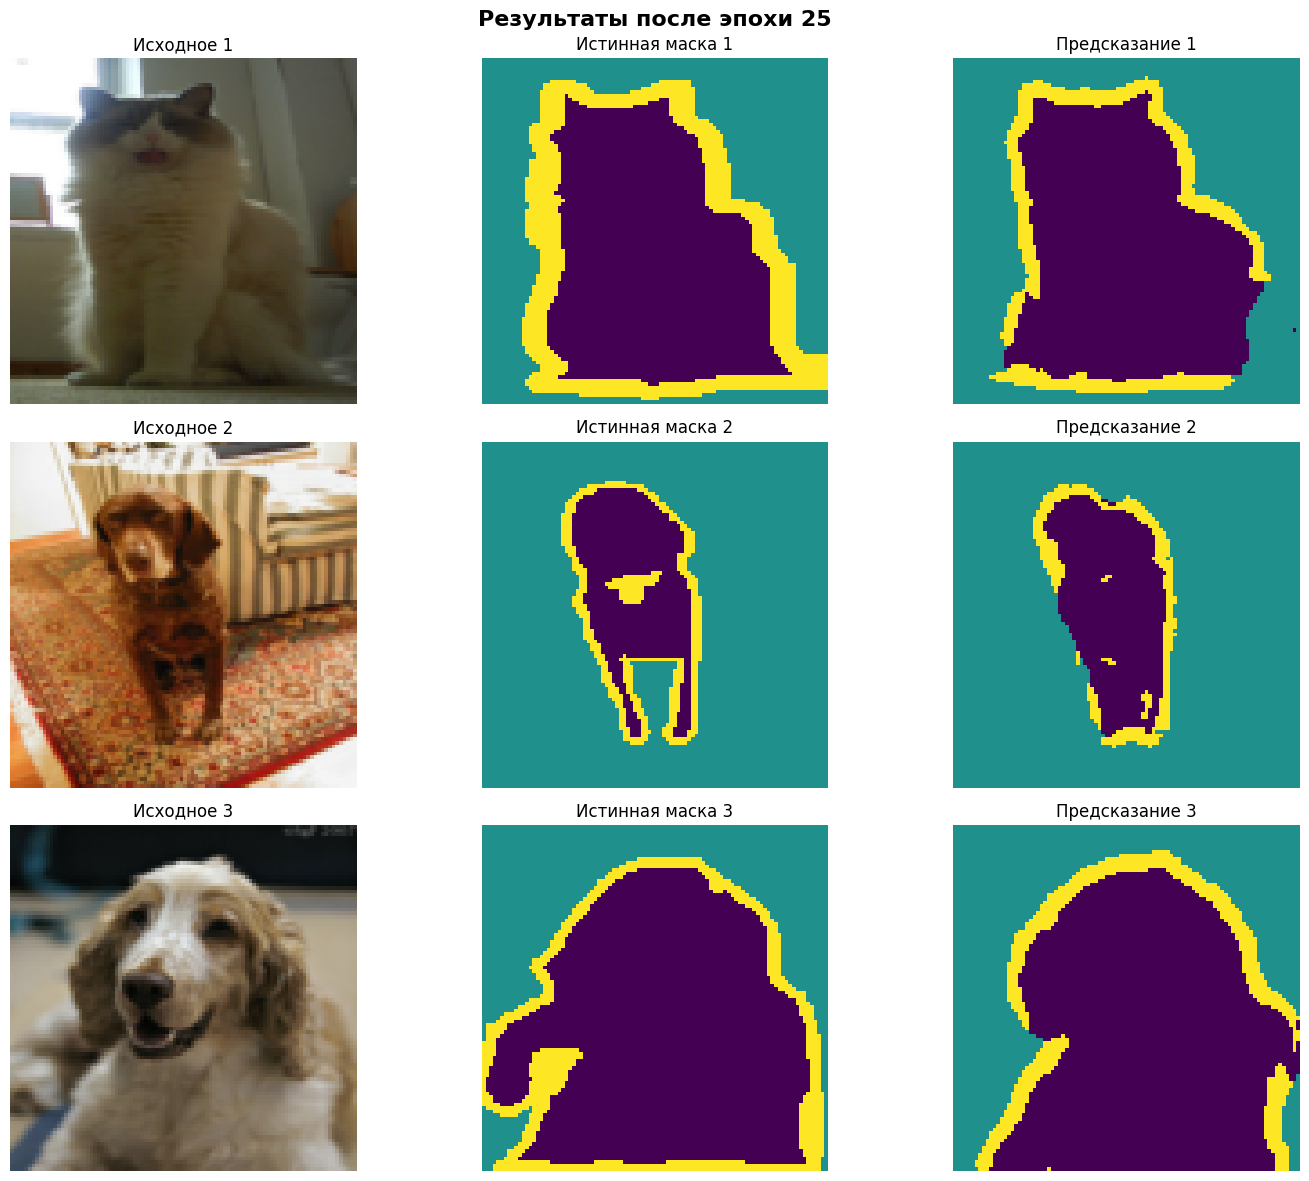

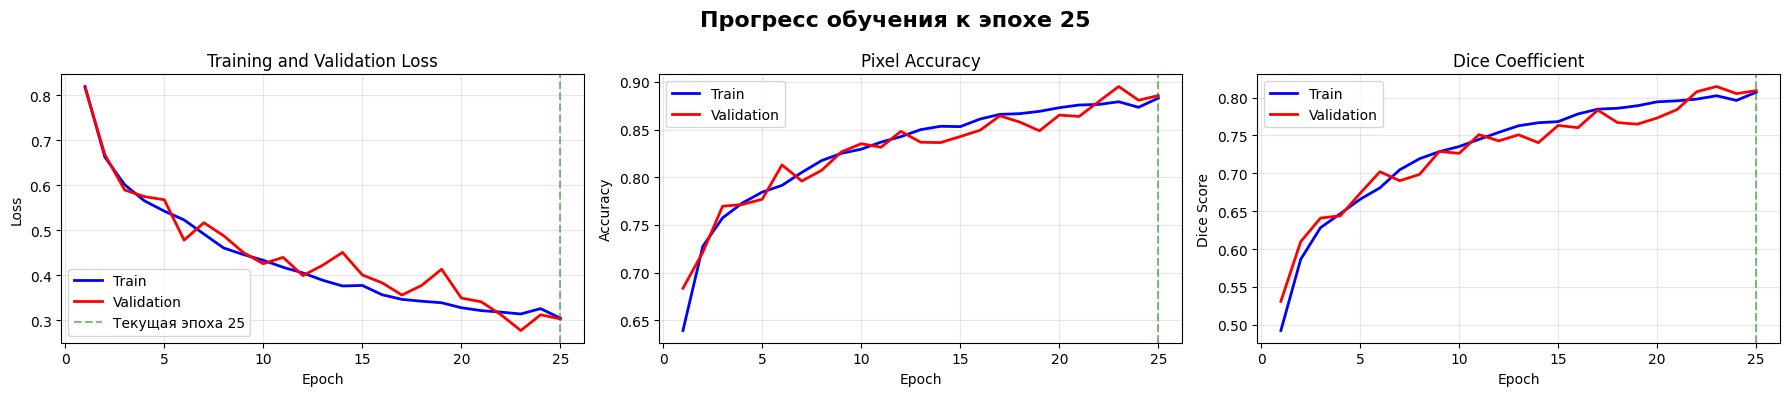


ЭПОХА 26/50


Val: 100%|██████████| 13/13 [00:10<00:00,  1.26it/s, loss=0.2936, acc=0.900]



Результаты эпохи 26:
  Train - Loss: 0.2943, Acc: 0.8861, Dice: 0.8120
  Val   - Loss: 0.3177, Acc: 0.8796, Dice: 0.8097
  LR: 0.001000
Без улучшений: 3/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 27/50


Val: 100%|██████████| 13/13 [00:10<00:00,  1.25it/s, loss=0.2425, acc=0.918]



Результаты эпохи 27:
  Train - Loss: 0.3079, Acc: 0.8797, Dice: 0.8048
  Val   - Loss: 0.3094, Acc: 0.8872, Dice: 0.8100
  LR: 0.001000
Без улучшений: 4/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 28/50


...


Результаты эпохи 28:
  Train - Loss: 0.2801, Acc: 0.8905, Dice: 0.8168
  Val   - Loss: 0.3166, Acc: 0.8807, Dice: 0.7998
  LR: 0.001000
Без улучшений: 5/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 29/50


Val: 100%|██████████| 13/13 [00:10<00:00,  1.23it/s, loss=0.2278, acc=0.916]



Результаты эпохи 29:
  Train - Loss: 0.2857, Acc: 0.8896, Dice: 0.8161
  Val   - Loss: 0.2738, Acc: 0.8967, Dice: 0.8227
  LR: 0.001000
Чекпоинт сохранён: checkpoints\unet_improved_best.pth
Новая лучшая модель! Loss: 0.2738
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 30/50


Val: 100%|██████████| 13/13 [00:10<00:00,  1.21it/s, loss=0.2127, acc=0.921]



Результаты эпохи 30:
  Train - Loss: 0.2734, Acc: 0.8933, Dice: 0.8210
  Val   - Loss: 0.2787, Acc: 0.8948, Dice: 0.8174
  LR: 0.001000
Без улучшений: 1/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth
Визуализация сохранена: visualizations\epoch_030.png


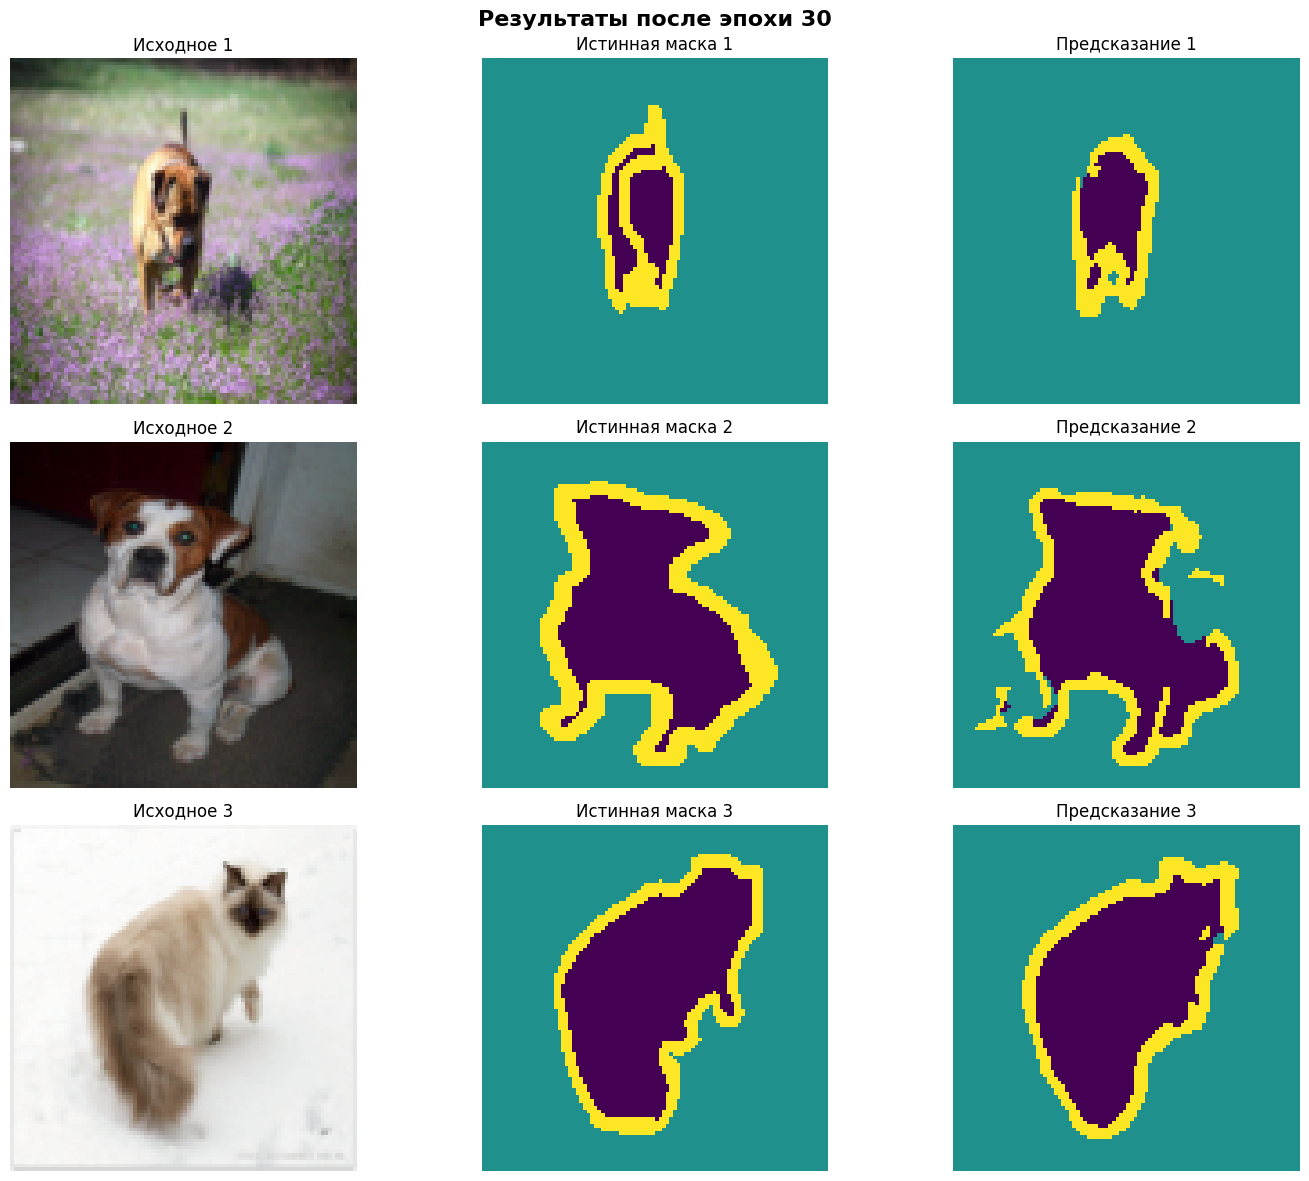

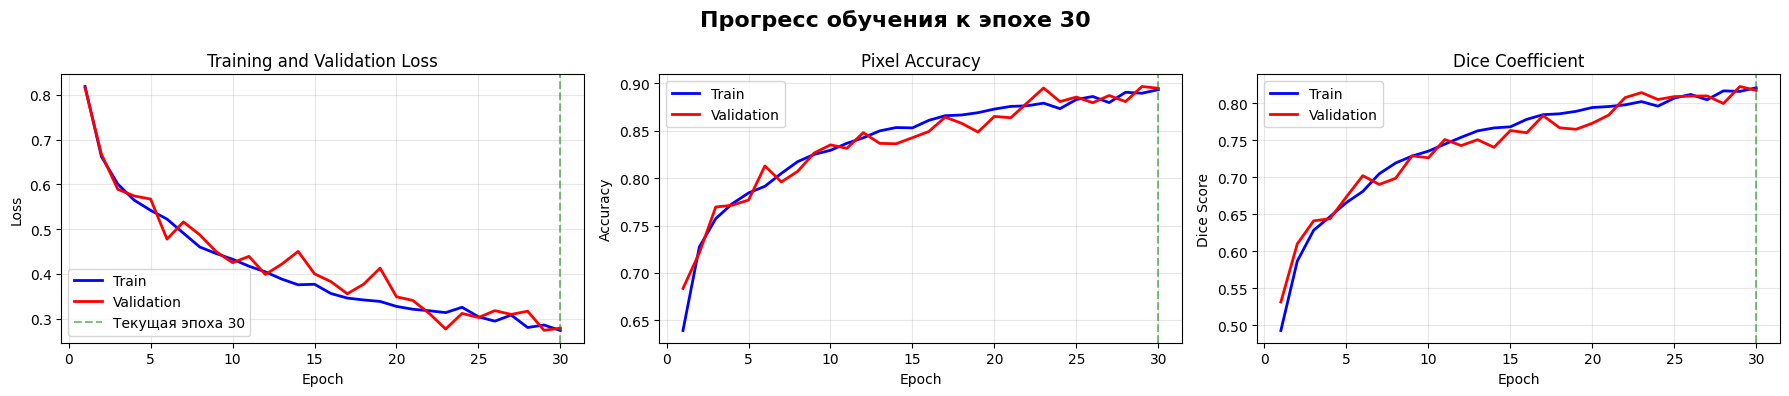


ЭПОХА 31/50


Val: 100%|██████████| 13/13 [00:10<00:00,  1.20it/s, loss=0.2294, acc=0.914]



Результаты эпохи 31:
  Train - Loss: 0.2753, Acc: 0.8934, Dice: 0.8212
  Val   - Loss: 0.2797, Acc: 0.8943, Dice: 0.8223
  LR: 0.001000
Без улучшений: 2/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 32/50


Val: 100%|██████████| 13/13 [00:10<00:00,  1.21it/s, loss=0.2424, acc=0.913]



Результаты эпохи 32:
  Train - Loss: 0.2633, Acc: 0.8970, Dice: 0.8256
  Val   - Loss: 0.3002, Acc: 0.8852, Dice: 0.8118
  LR: 0.001000
Без улучшений: 3/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 33/50


...


Результаты эпохи 33:
  Train - Loss: 0.2581, Acc: 0.8981, Dice: 0.8277
  Val   - Loss: 0.3141, Acc: 0.8817, Dice: 0.8095
  LR: 0.001000
Без улучшений: 4/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 34/50


Val: 100%|██████████| 13/13 [00:10<00:00,  1.20it/s, loss=0.2128, acc=0.921]



Результаты эпохи 34:
  Train - Loss: 0.2654, Acc: 0.8959, Dice: 0.8249
  Val   - Loss: 0.2659, Acc: 0.9002, Dice: 0.8332
  LR: 0.001000
Чекпоинт сохранён: checkpoints\unet_improved_best.pth
Новая лучшая модель! Loss: 0.2659
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 35/50


Val: 100%|██████████| 13/13 [00:10<00:00,  1.20it/s, loss=0.2371, acc=0.917]



Результаты эпохи 35:
  Train - Loss: 0.2583, Acc: 0.8987, Dice: 0.8290
  Val   - Loss: 0.2815, Acc: 0.8922, Dice: 0.8252
  LR: 0.001000
Без улучшений: 1/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth
Визуализация сохранена: visualizations\epoch_035.png


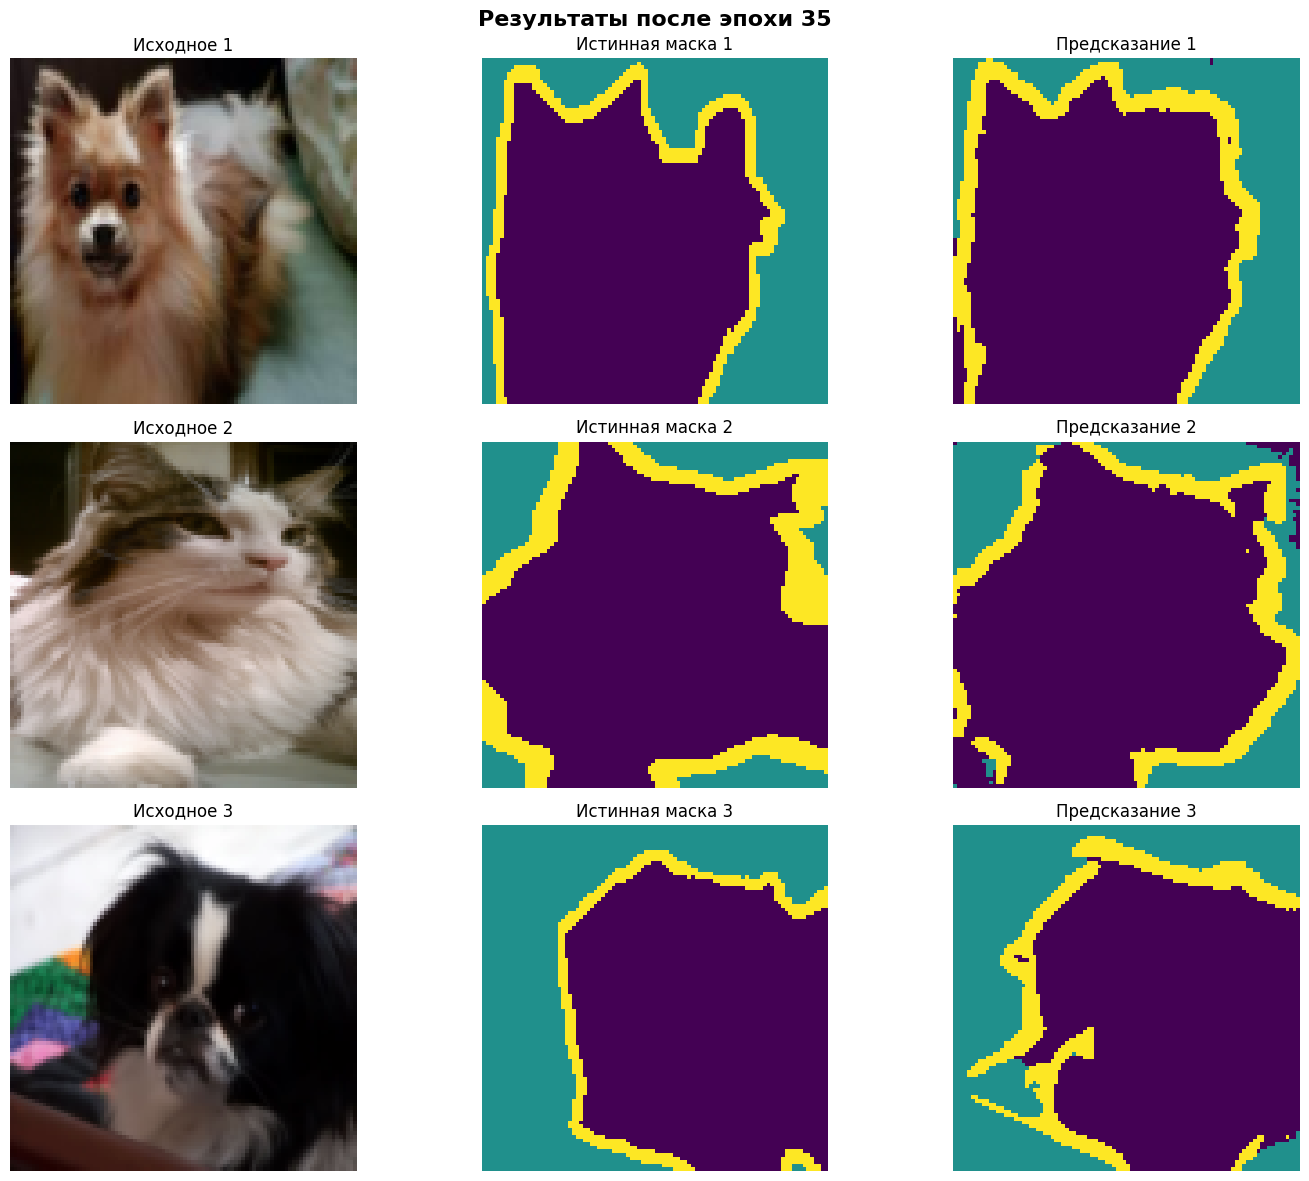

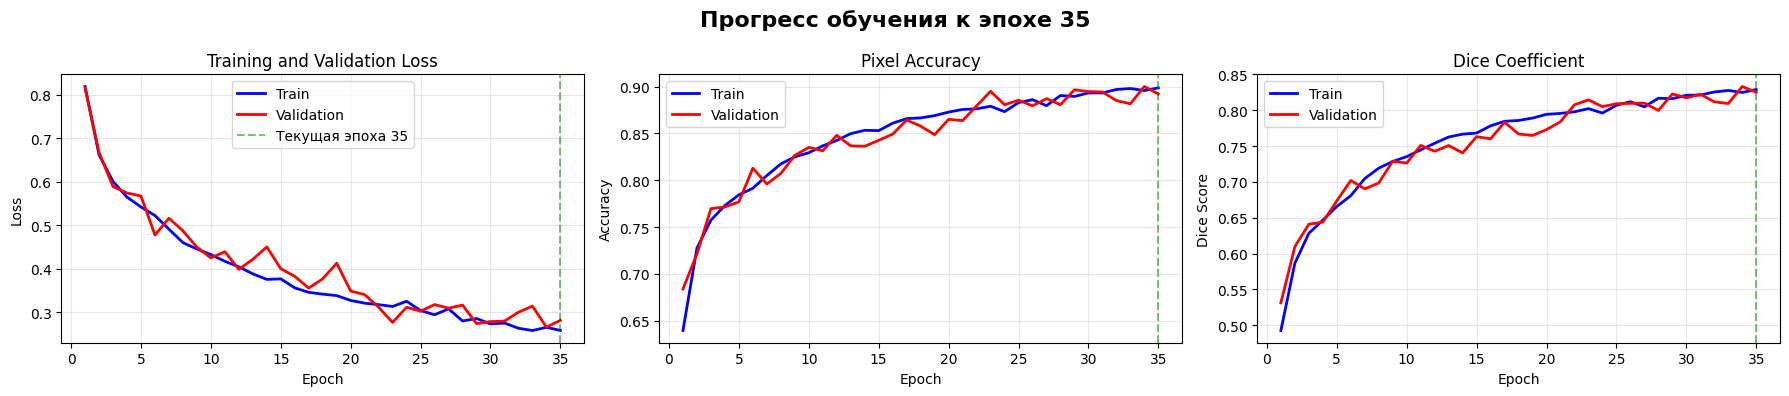


ЭПОХА 36/50


Val: 100%|██████████| 13/13 [00:11<00:00,  1.18it/s, loss=0.2407, acc=0.911]



Результаты эпохи 36:
  Train - Loss: 0.2612, Acc: 0.8979, Dice: 0.8271
  Val   - Loss: 0.2935, Acc: 0.8896, Dice: 0.8135
  LR: 0.001000
Без улучшений: 2/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 37/50


Val: 100%|██████████| 13/13 [02:00<00:00,  9.26s/it, loss=0.2237, acc=0.914]



Результаты эпохи 37:
  Train - Loss: 0.2578, Acc: 0.8996, Dice: 0.8286
  Val   - Loss: 0.2703, Acc: 0.8961, Dice: 0.8198
  LR: 0.001000
Без улучшений: 3/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 38/50


...


Результаты эпохи 38:
  Train - Loss: 0.2409, Acc: 0.9063, Dice: 0.8371
  Val   - Loss: 0.2730, Acc: 0.8960, Dice: 0.8232
  LR: 0.001000
Без улучшений: 4/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 39/50


Val: 100%|██████████| 13/13 [00:15<00:00,  1.21s/it, loss=0.2399, acc=0.915]



Результаты эпохи 39:
  Train - Loss: 0.2420, Acc: 0.9049, Dice: 0.8361
  Val   - Loss: 0.2932, Acc: 0.8922, Dice: 0.8166
  LR: 0.001000
Без улучшений: 5/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 40/50


Val: 100%|██████████| 13/13 [00:12<00:00,  1.02it/s, loss=0.2308, acc=0.916]



Результаты эпохи 40:
  Train - Loss: 0.2460, Acc: 0.9047, Dice: 0.8366
  Val   - Loss: 0.2982, Acc: 0.8895, Dice: 0.8223
  LR: 0.000500
Без улучшений: 6/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth
Визуализация сохранена: visualizations\epoch_040.png


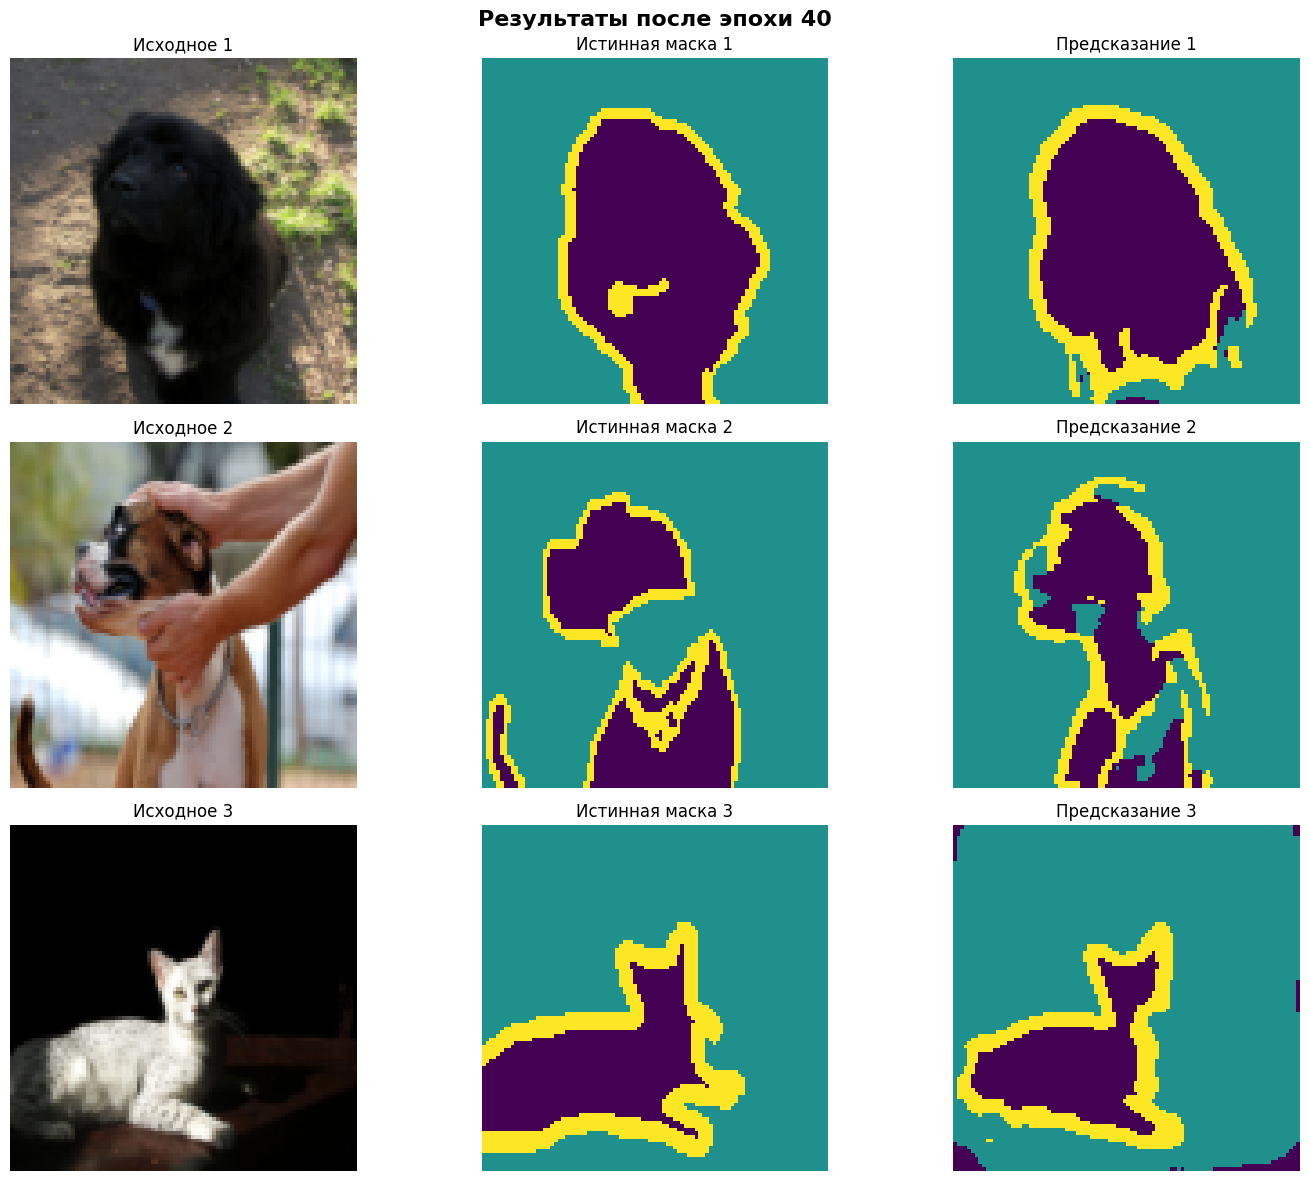

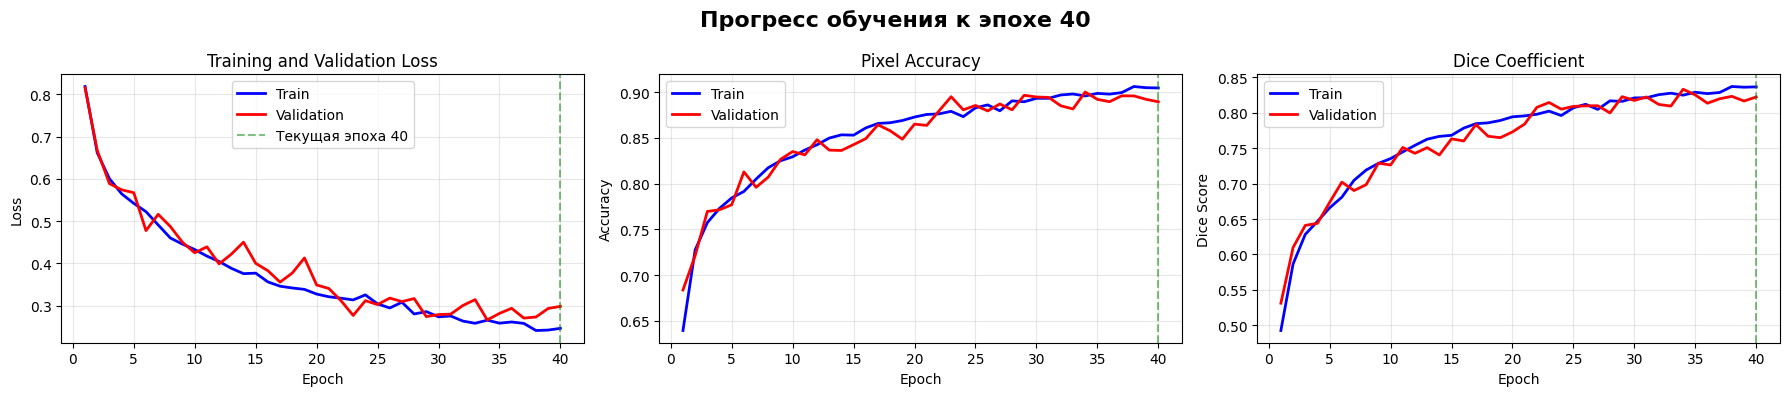


ЭПОХА 41/50


Val: 100%|██████████| 13/13 [01:01<00:00,  4.70s/it, loss=0.2118, acc=0.920]



Результаты эпохи 41:
  Train - Loss: 0.2235, Acc: 0.9124, Dice: 0.8462
  Val   - Loss: 0.2538, Acc: 0.9033, Dice: 0.8343
  LR: 0.000500
Чекпоинт сохранён: checkpoints\unet_improved_best.pth
Новая лучшая модель! Loss: 0.2538
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 42/50


Val: 100%|██████████| 13/13 [01:41<00:00,  7.83s/it, loss=0.1932, acc=0.931]



Результаты эпохи 42:
  Train - Loss: 0.2101, Acc: 0.9170, Dice: 0.8530
  Val   - Loss: 0.2639, Acc: 0.9027, Dice: 0.8349
  LR: 0.000500
Без улучшений: 1/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 43/50


...


Результаты эпохи 43:
  Train - Loss: 0.2078, Acc: 0.9178, Dice: 0.8544
  Val   - Loss: 0.2641, Acc: 0.9016, Dice: 0.8352
  LR: 0.000500
Без улучшений: 2/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 44/50


Val: 100%|██████████| 13/13 [00:09<00:00,  1.42it/s, loss=0.2065, acc=0.928]



Результаты эпохи 44:
  Train - Loss: 0.2040, Acc: 0.9192, Dice: 0.8564
  Val   - Loss: 0.2757, Acc: 0.8993, Dice: 0.8306
  LR: 0.000500
Без улучшений: 3/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 45/50


Val: 100%|██████████| 13/13 [00:09<00:00,  1.41it/s, loss=0.1982, acc=0.927]



Результаты эпохи 45:
  Train - Loss: 0.1998, Acc: 0.9206, Dice: 0.8575
  Val   - Loss: 0.2630, Acc: 0.9025, Dice: 0.8319
  LR: 0.000500
Без улучшений: 4/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth
Визуализация сохранена: visualizations\epoch_045.png


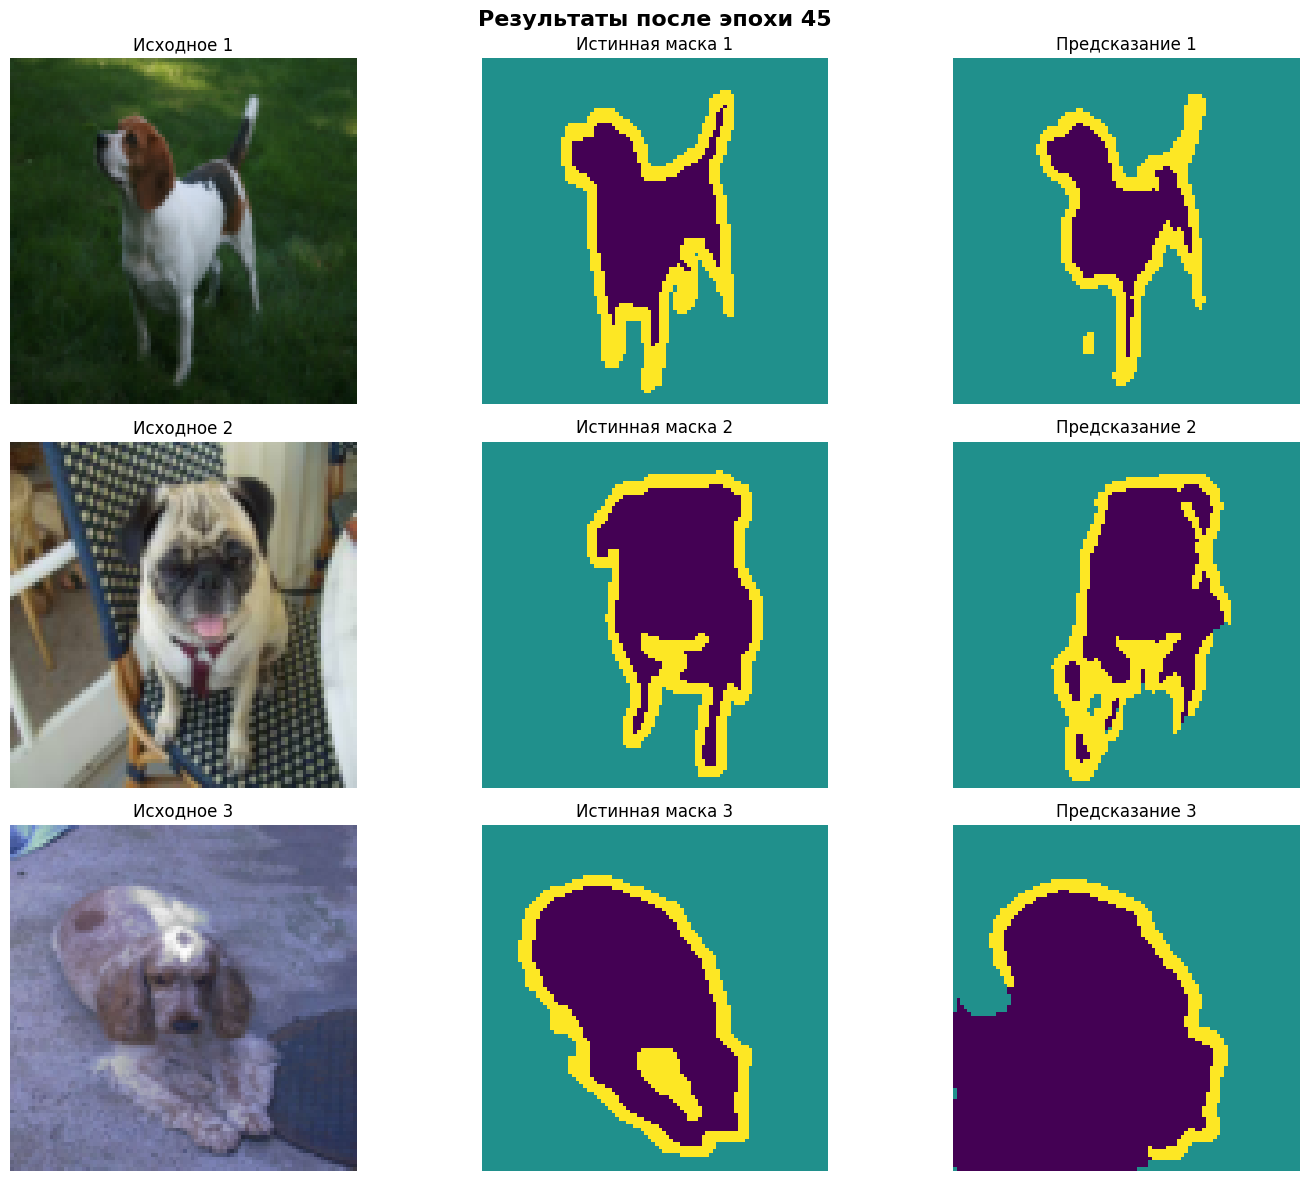

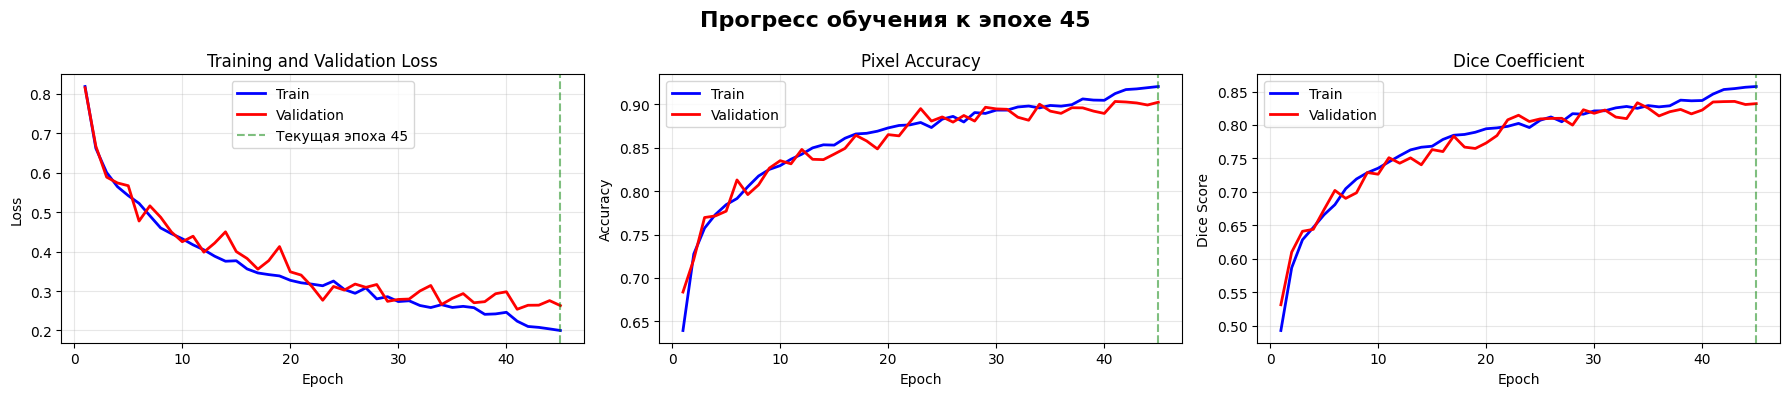


ЭПОХА 46/50


Val: 100%|██████████| 13/13 [00:09<00:00,  1.41it/s, loss=0.1995, acc=0.929]



Результаты эпохи 46:
  Train - Loss: 0.2008, Acc: 0.9208, Dice: 0.8585
  Val   - Loss: 0.2648, Acc: 0.9030, Dice: 0.8382
  LR: 0.000500
Без улучшений: 5/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 47/50


Val: 100%|██████████| 13/13 [00:09<00:00,  1.41it/s, loss=0.1954, acc=0.931]



Результаты эпохи 47:
  Train - Loss: 0.1969, Acc: 0.9214, Dice: 0.8596
  Val   - Loss: 0.2637, Acc: 0.9025, Dice: 0.8361
  LR: 0.000250
Без улучшений: 6/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 48/50


...


Результаты эпохи 48:
  Train - Loss: 0.1896, Acc: 0.9240, Dice: 0.8630
  Val   - Loss: 0.2670, Acc: 0.9020, Dice: 0.8374
  LR: 0.000250
Без улучшений: 7/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 49/50


Val: 100%|██████████| 13/13 [00:09<00:00,  1.40it/s, loss=0.2009, acc=0.929]



Результаты эпохи 49:
  Train - Loss: 0.1859, Acc: 0.9260, Dice: 0.8658
  Val   - Loss: 0.2682, Acc: 0.9037, Dice: 0.8377
  LR: 0.000250
Без улучшений: 8/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth

ЭПОХА 50/50


Val: 100%|██████████| 13/13 [00:09<00:00,  1.41it/s, loss=0.2035, acc=0.931]



Результаты эпохи 50:
  Train - Loss: 0.1839, Acc: 0.9261, Dice: 0.8661
  Val   - Loss: 0.2659, Acc: 0.9043, Dice: 0.8348
  LR: 0.000250
Без улучшений: 9/10
Чекпоинт сохранён: checkpoints\unet_improved_latest.pth
Визуализация сохранена: visualizations\epoch_050.png


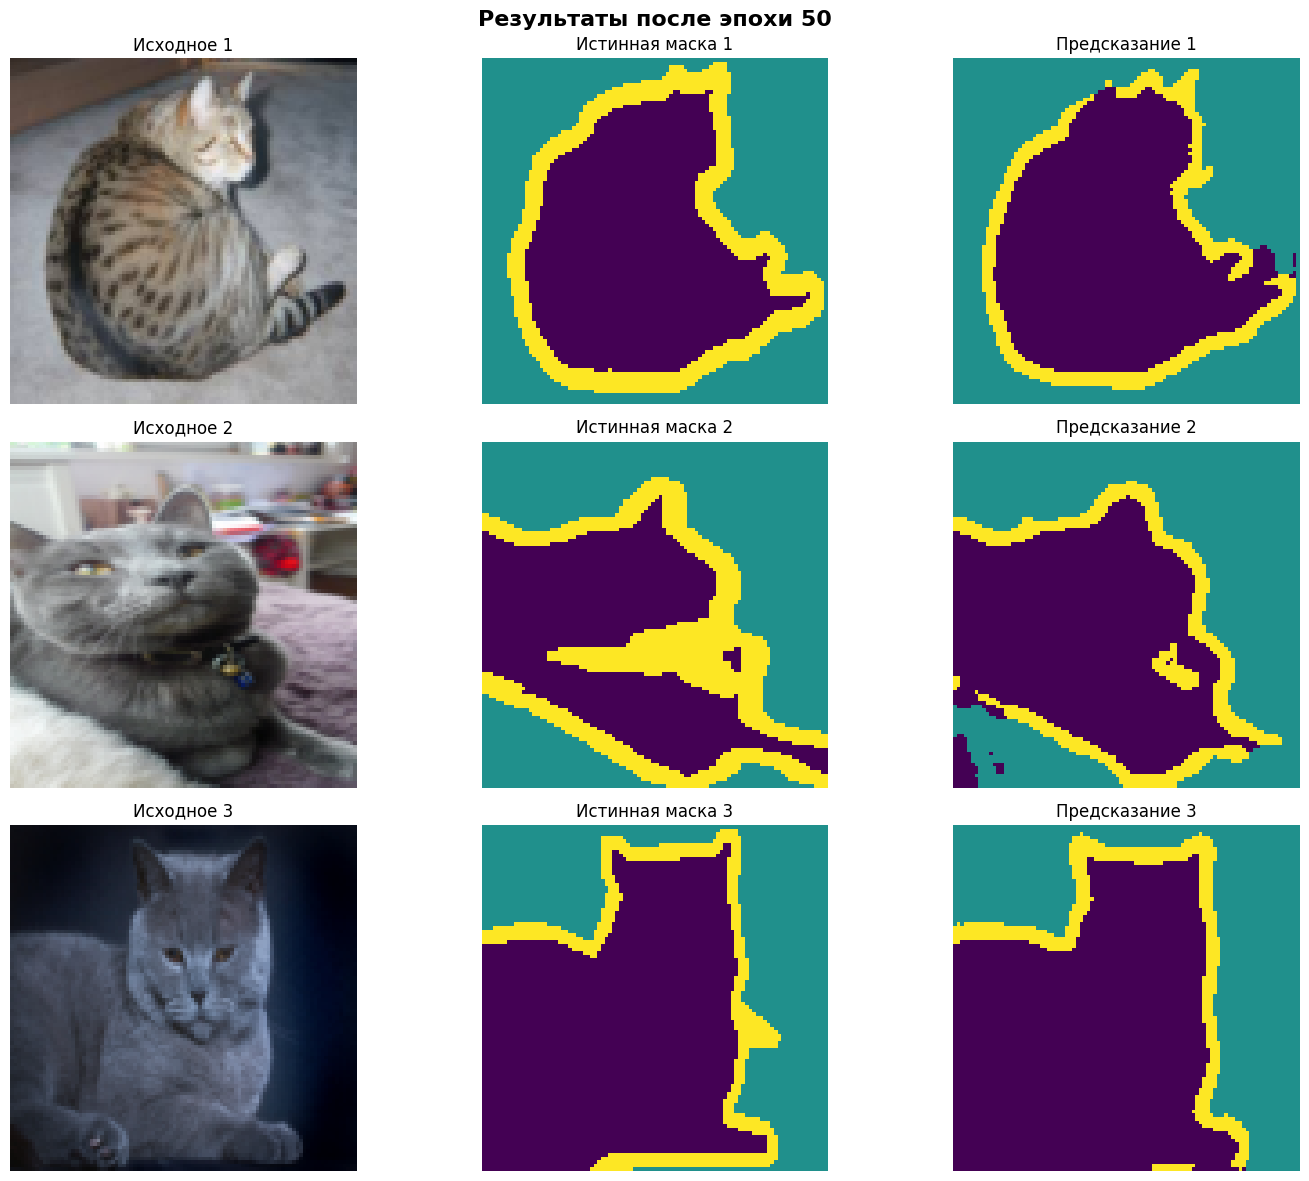

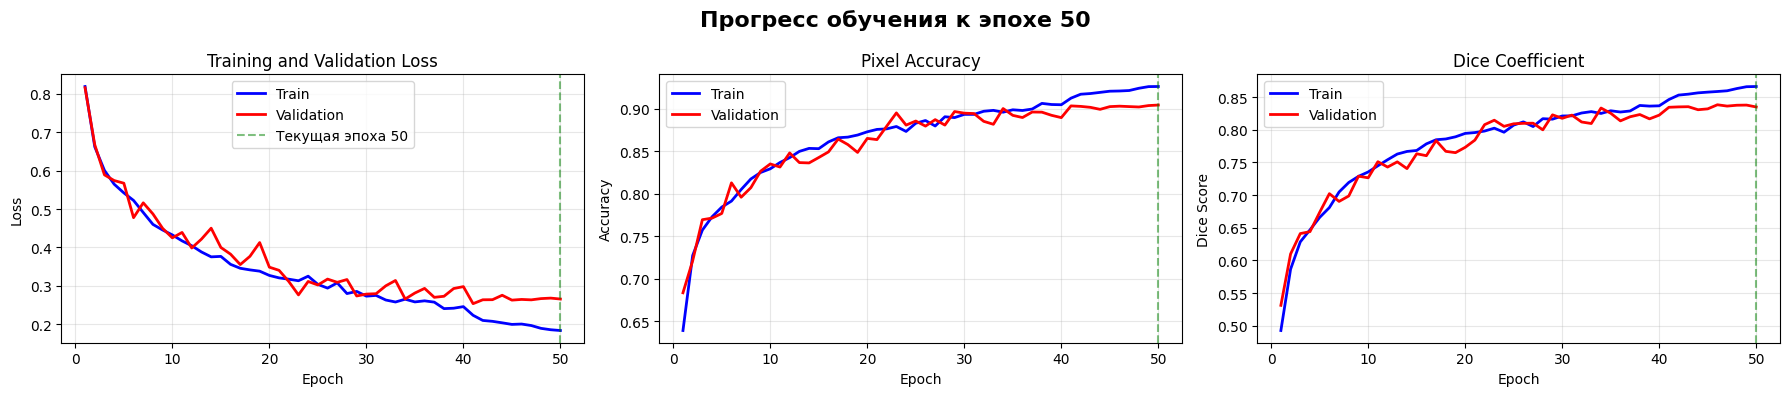


Обучение завершено! Всего эпох: 50


In [15]:
print("\n" + "="*60)
print("ПРОДОЛЖЕНИЕ ОБУЧЕНИЯ")
print("="*60)

patience_counter = 0

# Создаем папку для сохранения картинок по эпохам
VIZ_DIR = "visualizations"
os.makedirs(VIZ_DIR, exist_ok=True)

def show_epoch_predictions(model, loader, epoch, num_examples=3, save_fig=True):
    """Показывает и сохраняет предсказания для конкретной эпохи"""
    model.eval()
    
    fig, axes = plt.subplots(num_examples, 3, figsize=(15, num_examples*4))
    if num_examples == 1:
        axes = axes.reshape(1, -1)
    
    with torch.no_grad():
        for i in range(num_examples):
            idx = random.randint(0, len(loader.dataset)-1)
            img, true_mask = loader.dataset[idx]
            
            pred = model(img.unsqueeze(0).to(device))
            pred_mask = pred.argmax(dim=1).squeeze().cpu()
            
            # Денормализация
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
            img_display = img * std + mean
            img_display = torch.clamp(img_display, 0, 1)
            
            # Исходное
            axes[i, 0].imshow(img_display.permute(1,2,0))
            axes[i, 0].set_title(f'Исходное {i+1}', fontsize=12)
            axes[i, 0].axis('off')
            
            # Истинная маска
            axes[i, 1].imshow(true_mask, cmap='viridis')
            axes[i, 1].set_title(f'Истинная маска {i+1}', fontsize=12)
            axes[i, 1].axis('off')
            
            # Предсказание
            axes[i, 2].imshow(pred_mask, cmap='viridis')
            axes[i, 2].set_title(f'Предсказание {i+1}', fontsize=12)
            axes[i, 2].axis('off')
    
    plt.suptitle(f'Результаты после эпохи {epoch}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_fig:
        # Сохраняем в файл
        filename = os.path.join(VIZ_DIR, f'epoch_{epoch:03d}.png')
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"Визуализация сохранена: {filename}")
    
    plt.show()
    plt.close()

def plot_training_progress(history, epoch):
    """Рисует графики обучения с текущим прогрессом"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[0].axvline(x=epoch, color='g', linestyle='--', alpha=0.5, label=f'Текущая эпоха {epoch}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-', label='Validation', linewidth=2)
    axes[1].axvline(x=epoch, color='g', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Pixel Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Dice
    axes[2].plot(epochs, history['train_dice'], 'b-', label='Train', linewidth=2)
    axes[2].plot(epochs, history['val_dice'], 'r-', label='Validation', linewidth=2)
    axes[2].axvline(x=epoch, color='g', linestyle='--', alpha=0.5)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Dice Score')
    axes[2].set_title('Dice Coefficient')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle(f'Прогресс обучения к эпохе {epoch}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    # Сохраняем график
    plot_filename = os.path.join(VIZ_DIR, f'progress_epoch_{epoch:03d}.png')
    plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# Теперь сам цикл обучения с визуализацией
for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\n{'='*50}")
    print(f"ЭПОХА {epoch + 1}/{NUM_EPOCHS}")
    print(f"{'='*50}")
    
    # Обучение
    train_loss, train_acc, train_dice = train_epoch(model, train_loader, criterion, optimizer)
    
    # Валидация
    val_loss, val_acc, val_dice = validate(model, val_loader, criterion)
    
    # Сохраняем историю
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_dice'].append(train_dice)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_dice'].append(val_dice)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
    # Планировщик
    scheduler.step(val_loss)
    
    # Вывод результатов
    print(f"\nРезультаты эпохи {epoch + 1}:")
    print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Dice: {train_dice:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, Dice: {val_dice:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Сохраняем лучшую модель
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_path = os.path.join(CHECKPOINT_DIR, f"{MODEL_NAME}_best.pth")
        save_checkpoint(epoch, model, optimizer, scheduler, history, best_val_loss, best_path)
        patience_counter = 0
        print(f"Новая лучшая модель! Loss: {best_val_loss:.4f}")
    else:
        patience_counter += 1
        print(f"Без улучшений: {patience_counter}/{PATIENCE}")
    
    # Сохраняем последний чекпоинт
    latest_path = os.path.join(CHECKPOINT_DIR, f"{MODEL_NAME}_latest.pth")
    save_checkpoint(epoch, model, optimizer, scheduler, history, best_val_loss, latest_path)
    
    # show_epoch_predictions(model, val_loader, epoch + 1, num_examples=2, save_fig=True)
    # plot_training_progress(history, epoch + 1)

    # Показываем каждые PRINT_EVERY эпох
    if (epoch + 1) % PRINT_EVERY == 0:
        show_epoch_predictions(model, val_loader, epoch + 1, num_examples=3, save_fig=True)
        plot_training_progress(history, epoch + 1)
    
    # Ранняя остановка
    if patience_counter >= PATIENCE:
        print(f"\nРанняя остановка на эпохе {epoch + 1}")
        break

print(f"\nОбучение завершено! Всего эпох: {len(history['train_loss'])}")


ИТОГОВЫЕ РЕЗУЛЬТАТЫ


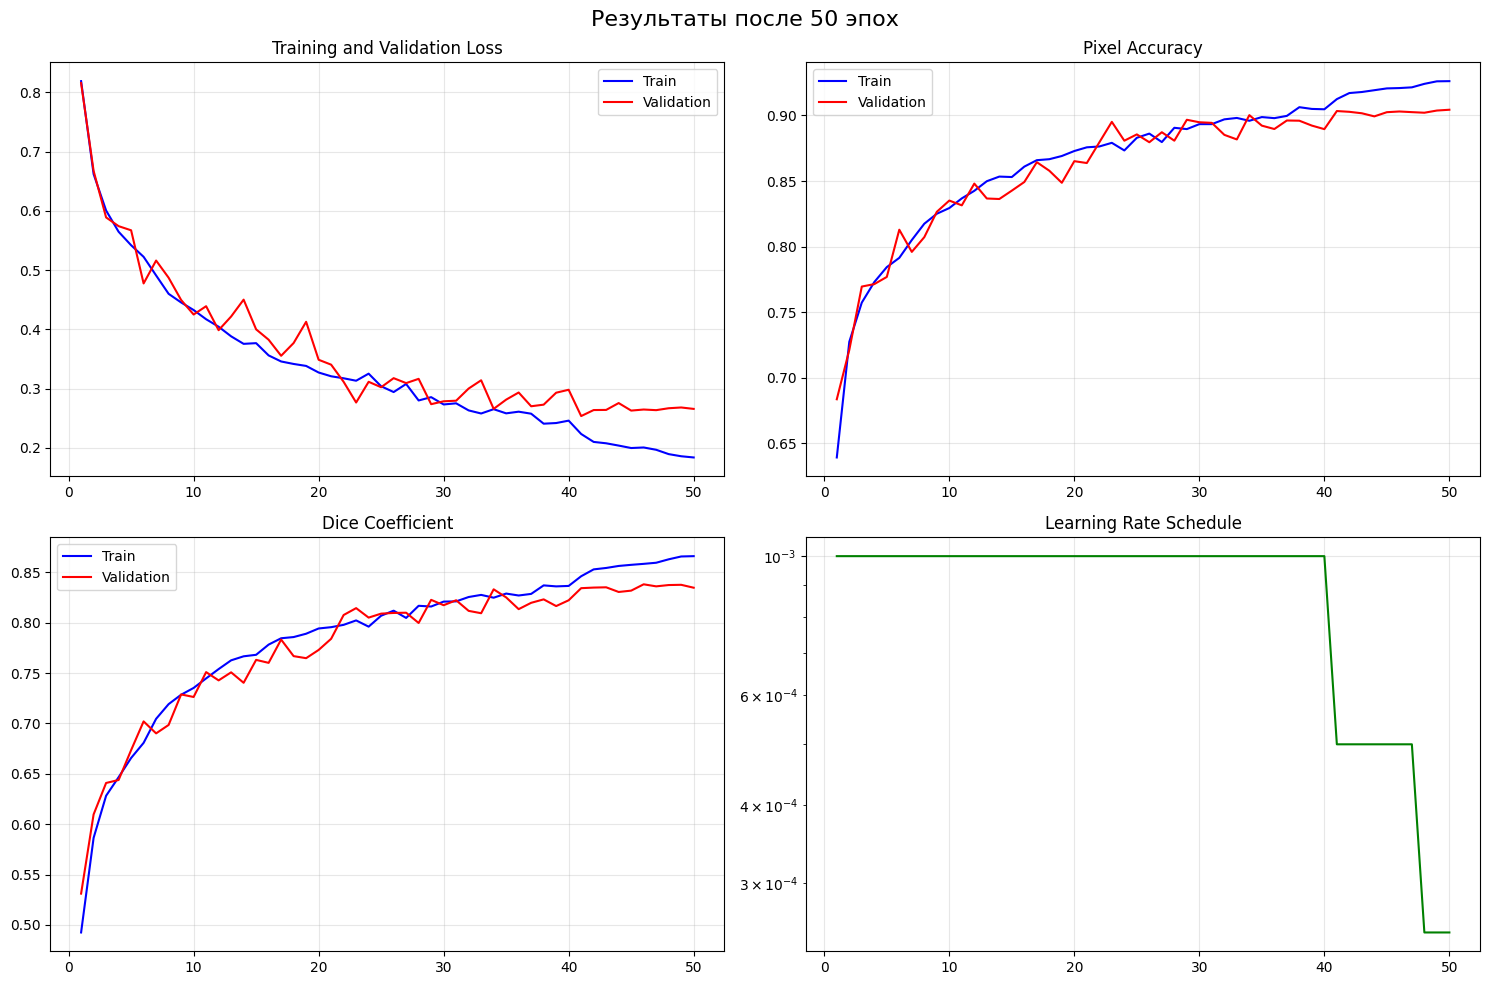


ФИНАЛЬНЫЕ МЕТРИКИ:
  Train Loss: 0.1839
  Val Loss: 0.2659
  Train Acc: 0.9261
  Val Acc: 0.9043
  Лучшая Val Loss: 0.2538


In [16]:
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*60)

# Графики
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train')
axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Validation')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train')
axes[0, 1].plot(epochs, history['val_acc'], 'r-', label='Validation')
axes[0, 1].set_title('Pixel Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Dice
axes[1, 0].plot(epochs, history['train_dice'], 'b-', label='Train')
axes[1, 0].plot(epochs, history['val_dice'], 'r-', label='Validation')
axes[1, 0].set_title('Dice Coefficient')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(epochs, history['lr'], 'g-')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Результаты после {len(history["train_loss"])} эпох', fontsize=16)
plt.tight_layout()
plt.show()

# Финальные метрики
print(f"\nФИНАЛЬНЫЕ МЕТРИКИ:")
print(f"  Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Val Loss: {history['val_loss'][-1]:.4f}")
print(f"  Train Acc: {history['train_acc'][-1]:.4f}")
print(f"  Val Acc: {history['val_acc'][-1]:.4f}")
print(f"  Лучшая Val Loss: {best_val_loss:.4f}")

# PS: обучение на предыдущих эпохах

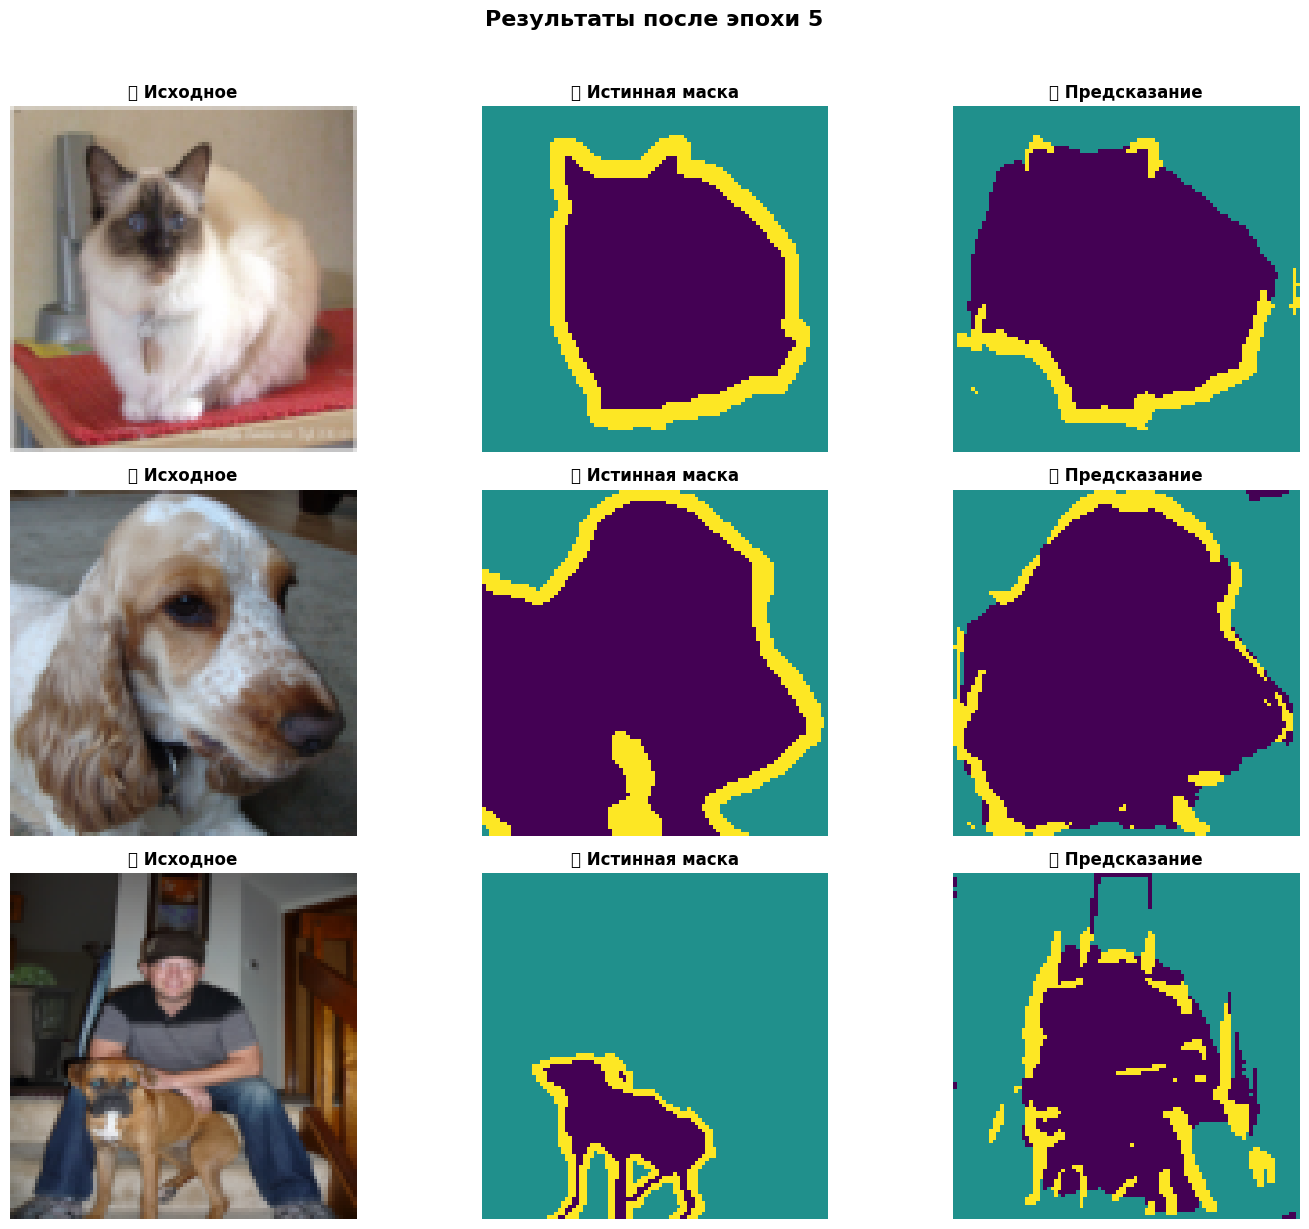

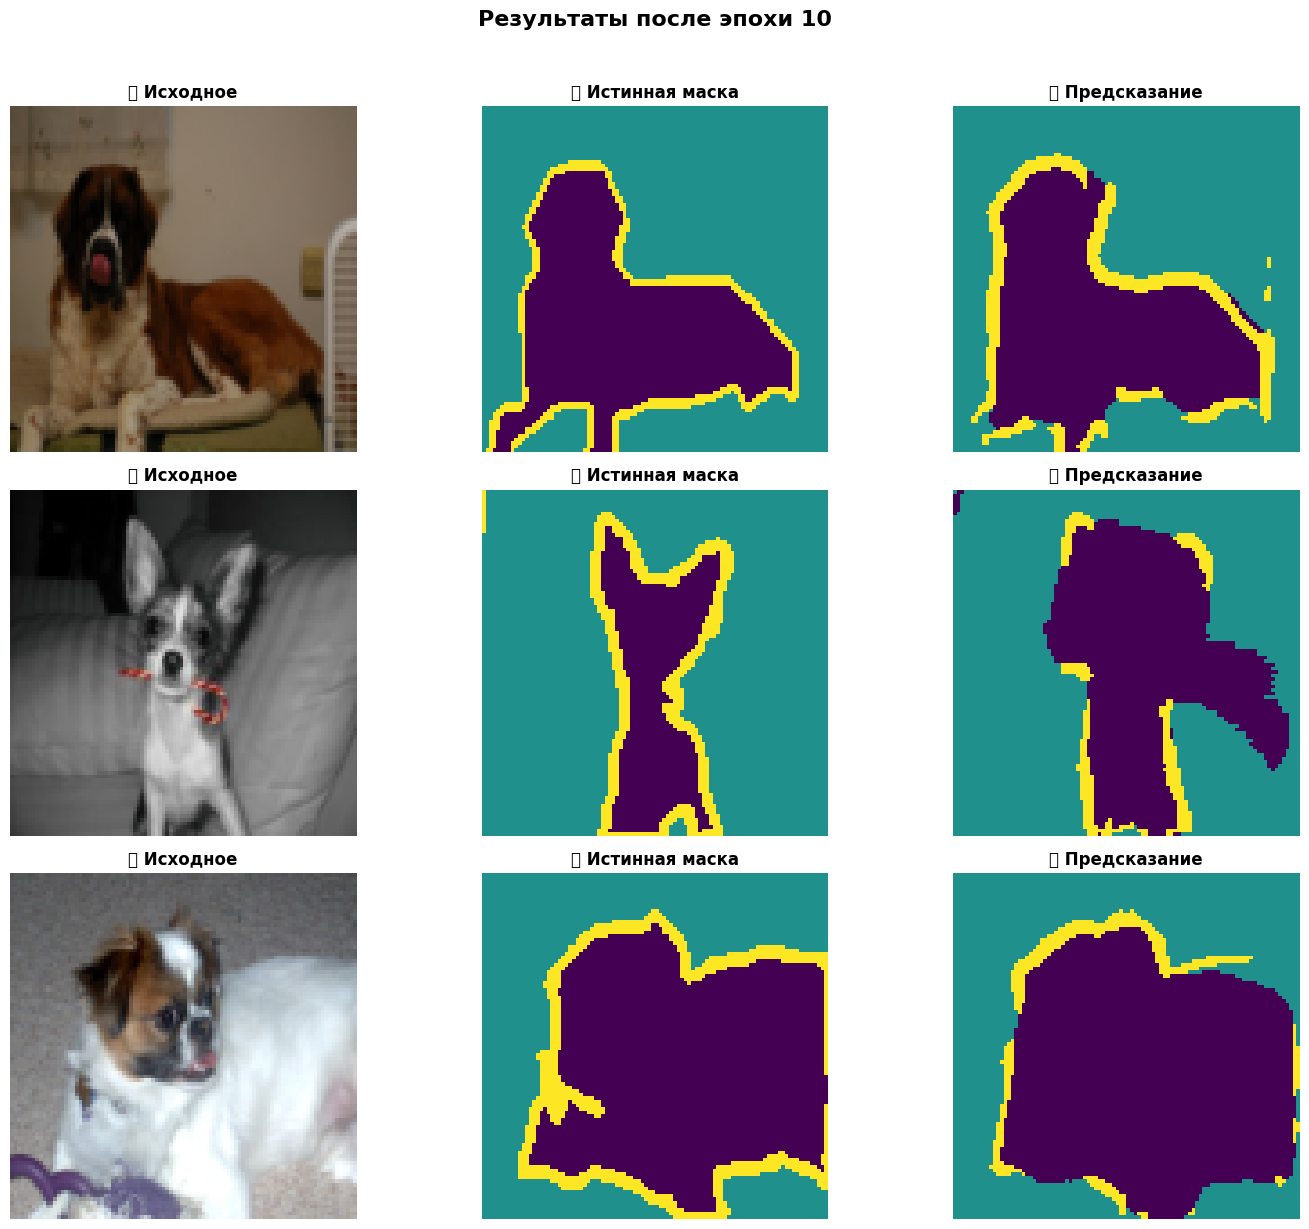

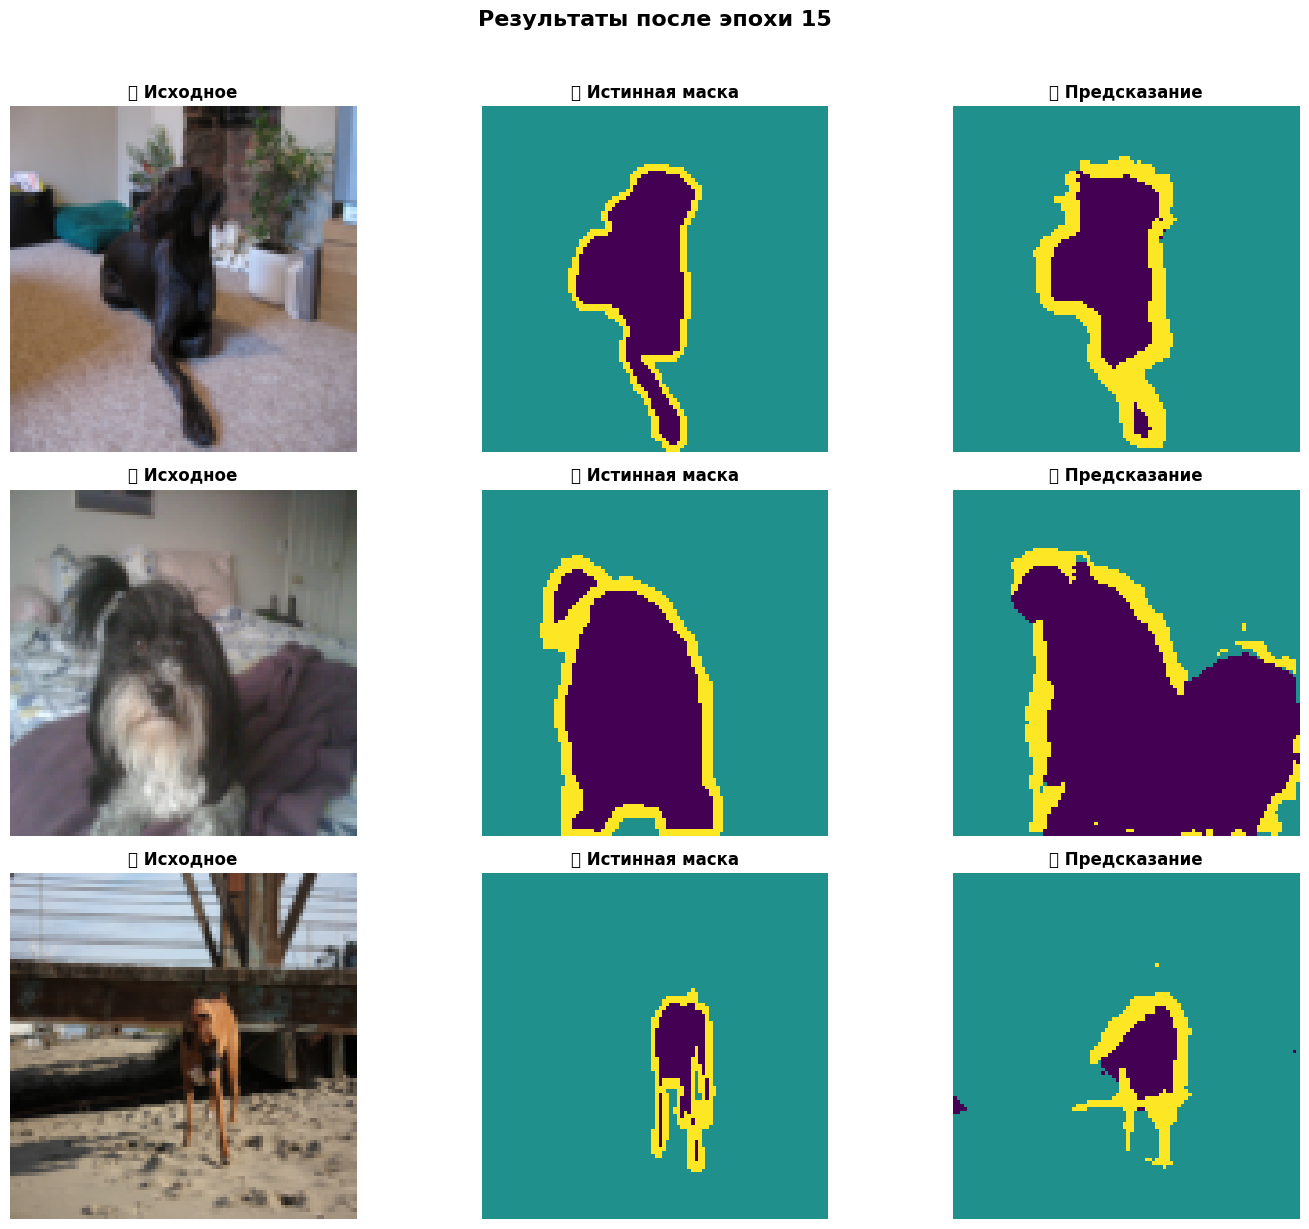

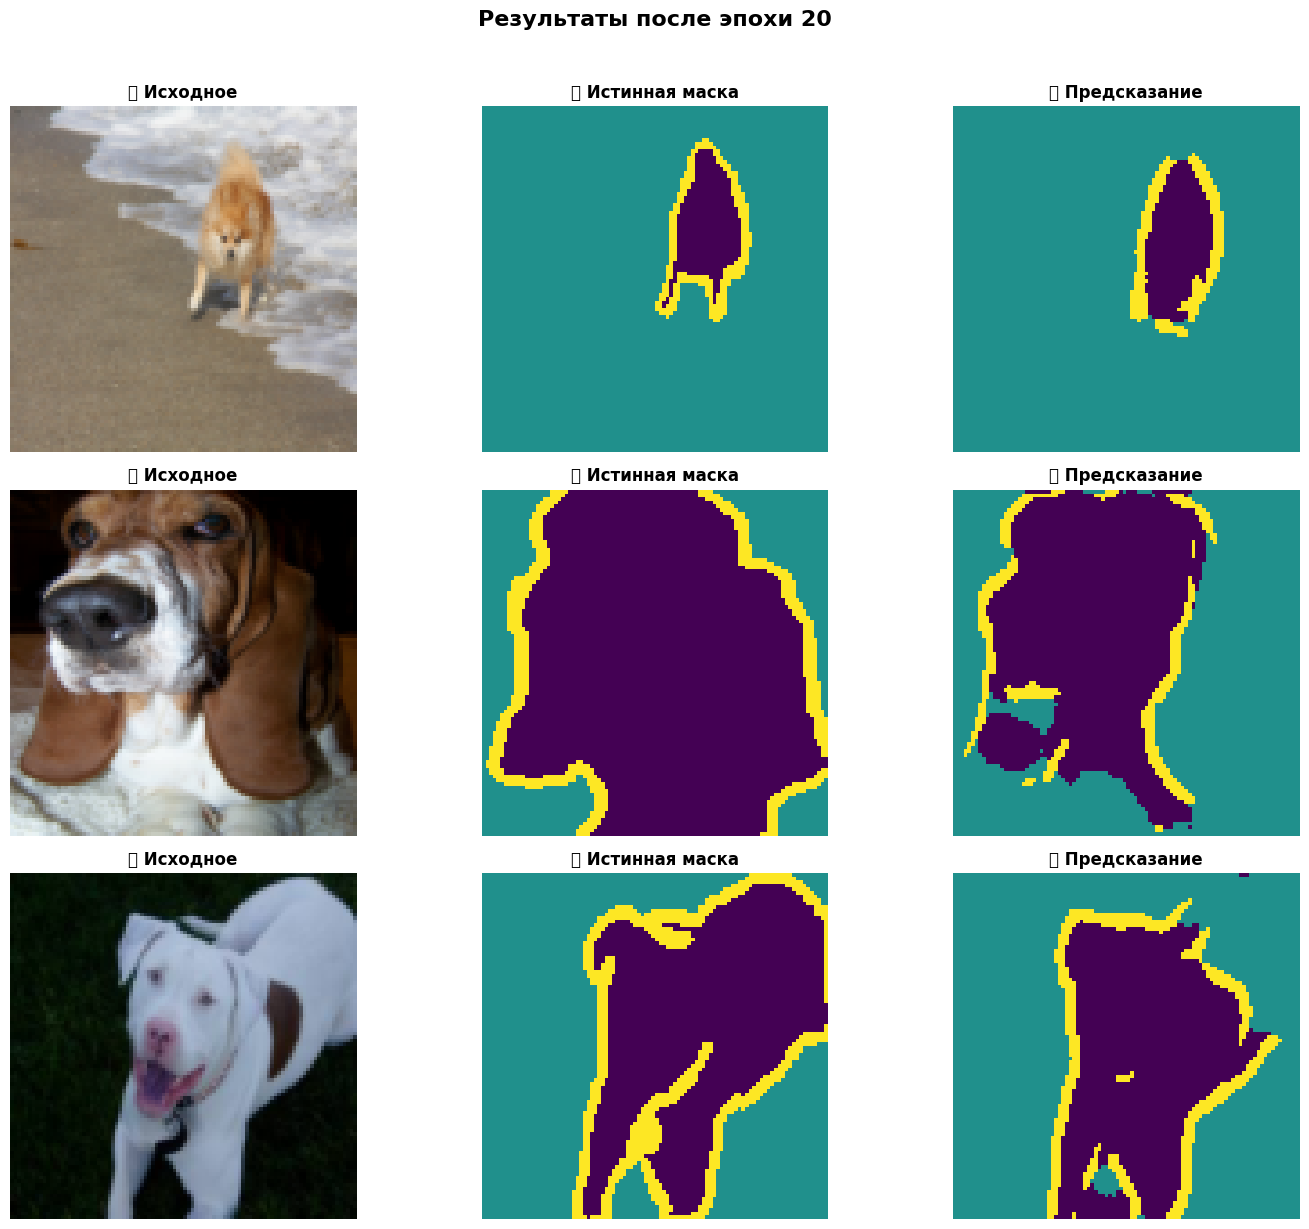